In [4]:
# Your Task


# 1. Data Preparation:

#     Download and explore the US Superstore data.
#     Perform basic data cleaning and preprocessing.


# 2. Data Visualization with Matplotlib:

#     Create an interactive line chart to show sales trends over the years.
#     Build an interactive map to visualize sales distribution by country.


# 3. Data Visualization with Seaborn:

#     Use Seaborn to generate a bar chart showing top 10 products by sales.
#     Create a scatter plot to analyze the relationship between profit and discount.


# 4. Comparative Analysis:

#     Compare the insights gained from Matplotlib and Seaborn visualizations.
#     Document your observations about the ease of use and effectiveness of both tools.


# 5. Code and Insights:

#     Write clear, well-documented Python code.
#     Include your analysis and insights as comments or markdown cells in your Jupyter notebook.


# Submit your Daily Challenge

# Share your Jupyter notebook on Github and highlight your key insights in the README file!

In [5]:
# 1. Data Preparation:

#     Download and explore the US Superstore data.
#     Perform basic data cleaning and preprocessing.
##Done in Mini Project. Copying from there:

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_excel('US Superstore data.xls')
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df_raw.shape

(9994, 21)

In [8]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [9]:
df_raw.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [10]:
df = df_raw.copy()
# Examining duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [11]:
#Examining rows w duplicate Order ID
df.duplicated(subset=['Order ID']).sum()


np.int64(4985)

In [12]:
duplicated_df = df[df.duplicated(subset=['Order ID'],keep=False)]
duplicated_df    

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,9988,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-AC-10001539,Technology,Accessories,Logitech G430 Surround Sound Gaming Headset wi...,79.9900,1,0.00,28.7964
9988,9989,CA-2017-163629,2017-11-17,2017-11-21,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Athens,...,30605,South,TEC-PH-10004006,Technology,Phones,Panasonic KX - TS880B Telephone,206.1000,5,0.00,55.6470
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932


In [13]:
#Conclusion: Rows with duplicate Order ID are normal, as they have different items ordered.
# I want to understand the sales column: is it total sales for that product (product price * quantity or only item price?)
# To do so I will look at rows with the same product ID.
df[df.duplicated(subset=['Product ID'],keep=False)].sort_values('Product ID')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
5494,5495,CA-2014-105249,2014-11-28,2014-11-28,Same Day,DH-13675,Duane Huffman,Home Office,United States,San Francisco,...,94122,West,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",411.332,4,0.15,-4.8392
1760,1761,CA-2015-130785,2015-09-05,2015-09-09,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,San Diego,...,92105,West,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",411.332,4,0.15,-4.8392
6401,6402,CA-2017-125472,2017-05-30,2017-05-31,First Class,BD-11725,Bruce Degenhardt,Consumer,United States,Lafayette,...,70506,South,FUR-BO-10000330,Furniture,Bookcases,"Sauder Camden County Barrister Bookcase, Plank...",241.960,2,0.00,33.8744
1594,1595,CA-2015-118423,2015-03-24,2015-03-27,First Class,DP-13390,Dennis Pardue,Home Office,United States,Peoria,...,61604,Central,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases,359.058,3,0.30,-35.9058
2603,2604,CA-2016-165848,2016-06-04,2016-06-04,Same Day,EN-13780,Edward Nazzal,Consumer,United States,New York City,...,10035,East,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases,136.784,1,0.20,5.1294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7501,7502,CA-2017-121048,2017-07-14,2017-07-18,Standard Class,TC-21295,Toby Carlisle,Consumer,United States,Westminster,...,92683,West,TEC-PH-10004977,Technology,Phones,GE 30524EE4,470.376,3,0.20,52.9173
7477,7478,CA-2014-167199,2014-01-06,2014-01-10,Standard Class,ME-17320,Maria Etezadi,Home Office,United States,Henderson,...,42420,South,TEC-PH-10004977,Technology,Phones,GE 30524EE4,391.980,2,0.00,113.6742
9727,9728,CA-2017-167395,2017-12-02,2017-12-04,First Class,KM-16720,Kunst Miller,Consumer,United States,Lowell,...,1852,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,979.950,5,0.00,284.1855
581,582,CA-2017-145233,2017-12-01,2017-12-05,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Denver,...,80219,West,TEC-PH-10004977,Technology,Phones,GE 30524EE4,470.376,3,0.20,52.9173


In [14]:
#We see that the Sales column in fact is different for different quanitites of the same Product ID so it captures the total sales (Product Price * Quantity.)
# Now for missing values:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [15]:
#No missing values.

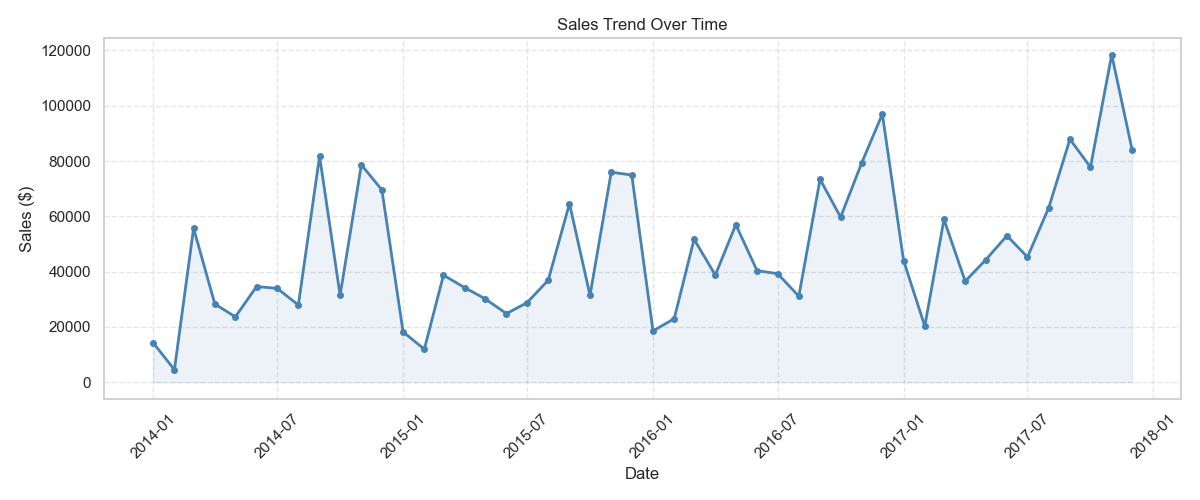

In [60]:
%matplotlib widget 
#     Create an interactive line chart to show sales trends over the years.
monthly = df.groupby(df['Order Date'].dt.to_period('M').dt.to_timestamp())['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, color='steelblue', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color='steelblue')
ax.set_title('Sales Trend Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Sales ($)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Hover tooltip
annot = ax.annotate('', xy=(0,0), xytext=(15,15), textcoords='offset points',
                    bbox=dict(boxstyle='round', fc='white', ec='gray'),
                    arrowprops=dict(arrowstyle='->'))
annot.set_visible(False)

def on_hover(event):
    if event.inaxes == ax:
        idx = (np.abs(monthly.index.map(pd.Timestamp.timestamp) - event.xdata)).argmin()
        annot.xy = (monthly.index[idx], monthly.values[idx])
        annot.set_text(f"{monthly.index[idx].strftime('%b %Y')}\n${monthly.values[idx]:,.0f}")
        annot.set_visible(True)
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_hover)
plt.tight_layout()
plt.show()

In [21]:
#     Build an interactive map to visualize sales distribution by country.
import plotly.express as px

# 1. Aggregate Sales by Country
country_data = df.groupby('Country')['Sales'].sum().reset_index()

# 2. Create the Interactive Choropleth Map
fig = px.choropleth(
    country_data, 
    locations="Country",         # The column with country names
    locationmode='country names', # Tells Plotly to match names to the map
    color="Sales",               # The metric used for shading
    hover_name="Country",        # Text to show in the header of the tooltip
    color_continuous_scale=px.colors.sequential.YlGnBu, # Modern Yellow-Green-Blue scale
    title="Total Sales by Country"
)

# 3. Enhance the layout
fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='equirectangular'
    )
)

fig.show()

C:\Users\benbo\AppData\Local\Temp\ipykernel_50396\1302825917.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [28]:
#This seems silly, as all the data is from purchases in one country, the US. So here is an interactive map of sales distribution by state:
import pandas as pd
import plotly.express as px

# 1. Prepare State Abbreviation Dictionary
us_state_to_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA', 'Colorado': 'CO',
    'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA',
    'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC', 'South Dakota': 'SD',
    'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# 2. Aggregate Sales by State (using your original 'df')
state_data = df.groupby('State').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

# 3. Add the 2-letter state codes required for the map
state_data['State_Code'] = state_data['State'].map(us_state_to_abbrev)

# 4. Create the Interactive Choropleth Map
fig = px.choropleth(
    state_data,
    locations='State_Code',      # Use the 2-letter codes for mapping
    locationmode="USA-states",   # Tell Plotly we are mapping US States
    color='Sales',               # Shading intensity based on Sales
    hover_name='State',          # Show full State name in the tooltip header
    hover_data={                 # Customize what appears in the tooltip
        'Sales': ':$,.2f', 
        'Profit': ':$,.2f', 
        'State_Code': False
    },
    scope="usa",                 # Focus the map on the USA only
    color_continuous_scale="Plasma", 
    title='Total Sales Distribution by State'
)

# 5. Final Layout Polish
fig.update_layout(
    margin={"r":0,"t":70,"l":0,"b":0},
    title_x=0.5, # Center the title
    geo_scope='usa'
)

# 6. Display the Map
fig.show()

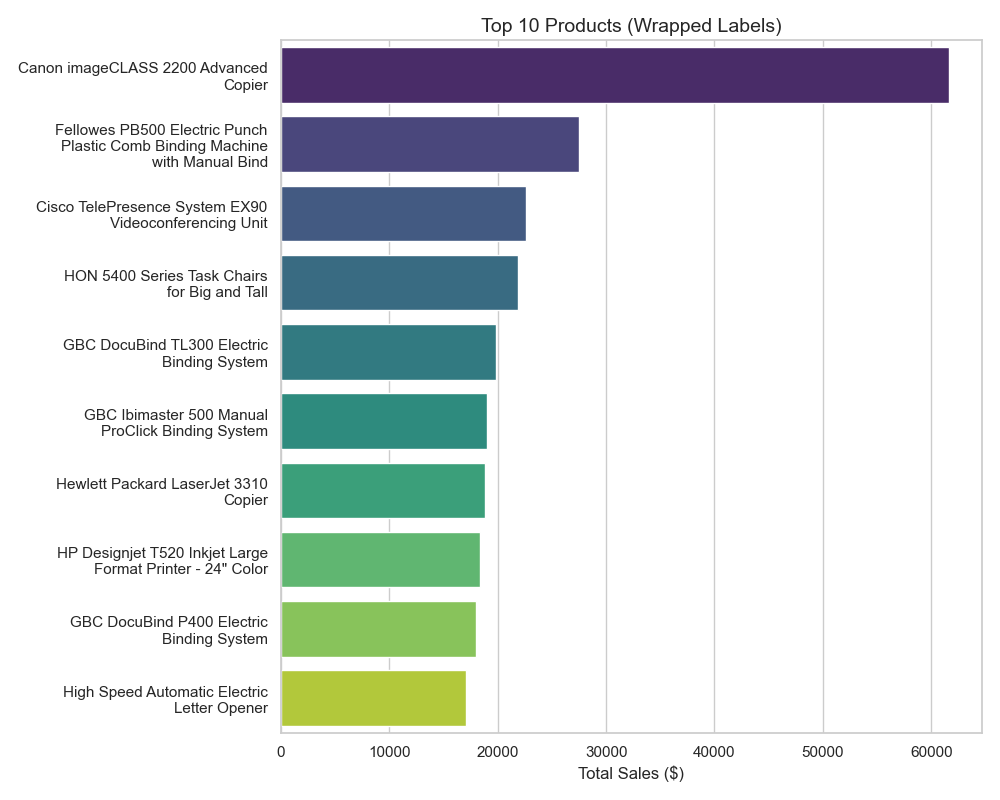

In [54]:
# Use Seaborn to generate a bar chart showing top 10 products by sales.
product_sales = df.groupby('Product Name').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
TopTenProducts = product_sales.sort_values('Sales',ascending=False).head(10)
import textwrap
TopTenProducts['Wrapped Name'] = TopTenProducts['Product Name'].apply(lambda x: textwrap.fill(x, width=30))

# 2. Plot using the new 'Wrapped Name' column
plt.figure(figsize=(10, 8)) # You can now make the width smaller (e.g., 10 instead of 14)

sns.barplot(
    data=TopTenProducts, 
    x='Sales', 
    y='Wrapped Name',
    hue='Wrapped Name',legend=False, 
    palette='viridis'
)

plt.title('Top 10 Products (Wrapped Labels)', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('') # Remove y-label to save more horizontal space
plt.tight_layout()
plt.show()

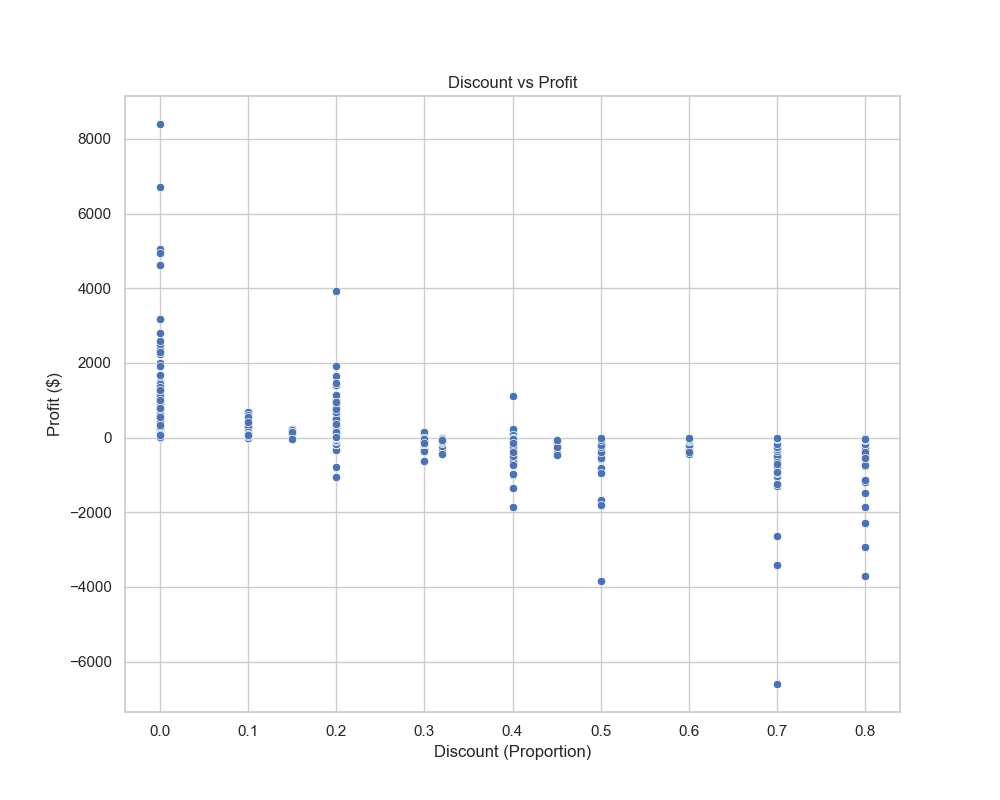

In [59]:
# Create a scatter plot to analyze the relationship between profit and discount.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Discount',y='Profit')
plt.title('Discount vs Profit')
plt.xlabel('Discount (Proportion)')
plt.ylabel('Profit ($)')
plt.show()

4. Comparative Analysis:

    Compare the insights gained from Matplotlib and Seaborn visualizations.
The Matplotlib visualizations showed how sales varied over time and how sales varied among different states. The Seaborn visualizations showed clearly the top ten products in terms of sales, making it easy to see that one product had a lot higher sales than others, and the relationship between discount and profit, showing that in cases with higher discounts the profit was lower.
    Document your observations about the ease of use and effectiveness of both tools.
    Both tools are effective. Matplotlib is great for when we want to arrange specific parameters regarding a chart. Seaborn is a bit easier to use in many cases and offers additional capabilities requiring limited input.
